<a href="https://colab.research.google.com/github/davidmkidd/AI-Driven-Climate-Risk-Prediction-and-Mitigation-Framework/blob/main/Tutorial_1_ESG_Report_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 1: ESG Report Analysis

**By Tobias Schimanski and based on my paper: "Bridiging the Gap in ESG Measurement: Using NLP to Quantify Environmental, Social, and Governance Communication"**

This notebook serves as a basis for applying AI Natural Language Processing tools to corporate sustainability reports. It is particularily tailored for newcomers to the field with limited or no prior experience. In this tutorial, you can only press play and will be fine.

If you are already advanced, you might just [want to read the paper](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4622514) and or go directly to the [models on HuggingFace](https://huggingface.co/ESGBERT).

**In this tutorial, we learn to analyse a annual report towards ESG risks and opportunities.**

## Import libraries

We start by importing some standard libraries as well as the "transformers" one. This will help us to use the tools.

In [ ]:
!pip install transformers
!pip install tika

  Preparing metadata (setup.py) ... done
  Created wheel for tika: filename=tika-2.6.0-py3-none-any.whl size=32624 sha256=f7afb4f58dae5058496ea94712f74c975df09ecba3e9a181453375c2a8d99997
  Stored in directory: /root/.cache/pip/wheels/27/ba/2f/37420d1191bdae5e855d69b8e913673045bfd395cbd78ad697
Successfully built tika


In [ ]:
# standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline # for using the models

import spacy # for sentence extraction
from tika import parser # for the report extraction

## Step 1: Get a feeling for the models

We are going to use models of the [ESG BERT project](https://huggingface.co/ESGBERT). In this tutorial, we don't use GPUs which would speed up the process enourmously.

In [ ]:
### Load the models (takes ca. 1 min)
# Environmental model.
name = "ESGBERT/EnvironmentalBERT-environmental" # path to download from HuggingFace
# In simple words, the tokenizer prepares the text for the model and the model classifies the text-
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
# The pipeline combines tokenizer and model to one process.
pipe_env = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Also load the social and governance model.
# Social model.
name = "ESGBERT/SocialBERT-social"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
pipe_soc = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Governance model.
name = "ESGBERT/GovernanceBERT-governance"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
pipe_gov = pipeline("text-classification", model=model, tokenizer=tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Device set to use cpu


Now, we downloaded models, tokenizer and create the pipeline. This means, we're already ready to go with the classification.

In [ ]:
# You can input single sentences or arrays of sentences into the pipeline,
sentences_test = ["Besides financial considerations, we also consider harms to the biodiversity and broader ecosystem impacts.",
                  "Scope 1 emissions are reported here on a like-for-like basis against the 2013 baseline and exclude emissions from additional vehicles used during repairs.",
                  "Tokenization is used in natural language processing to split paragraphs and sentences into smaller units that can be more easily assigned meaning.",
                  "Female representation in boards is important."]
test = pipe_soc(sentences_test)
print(test)

[{'label': 'none', 'score': 0.9999330043792725}, {'label': 'none', 'score': 0.9998942613601685}, {'label': 'none', 'score': 0.9999074935913086}, {'label': 'social', 'score': 0.9998486042022705}]


In [ ]:
# Only output the label of the first sentence.
print(test[0]["label"]) # label of first element

none


You can observe an array of lists as output. The first value gives you the label which could be "environmental" or "none". Furthermore, the 'score' gives you an indication of the confidence of the model in its decision. Play around yourself with the other models and produce example outputs.

In [ ]:
# Try it yourself. Insert a sentence.
sentences_test_2 = ["A"]
test = pipe_soc(sentences_test_2)
print(test)

[{'label': 'none', 'score': 0.9920573830604553}]


## Step 2: Extract texts from PDFs

Since this tutorial aims to classify the texts in a complete report, we now download an annual report and split it into single sentences.

In [ ]:
# We use the AUDI annual report to analyse in this example.
path = "https://www.audi.com/content/dam/gbp2/downloads/report/annual-reports/2022/en/audi-report-2022.pdf"

# The from_file() function of tika helps us to load the content of the document. (take ca. 30 sec)
report = parser.from_file(path)

2025-03-19 01:37:29,252 [MainThread  ] [INFO ]  Retrieving https://www.audi.com/content/dam/gbp2/downloads/report/annual-reports/2022/en/audi-report-2022.pdf to /tmp/content-dam-gbp2-downloads-report-annual-reports-2022-en-audi-report-2022.pdf.
INFO:tika.tika:Retrieving https://www.audi.com/content/dam/gbp2/downloads/report/annual-reports/2022/en/audi-report-2022.pdf to /tmp/content-dam-gbp2-downloads-report-annual-reports-2022-en-audi-report-2022.pdf.
2025-03-19 01:37:32,616 [MainThread  ] [INFO ]  Retrieving http://search.maven.org/remotecontent?filepath=org/apache/tika/tika-server-standard/2.6.0/tika-server-standard-2.6.0.jar to /tmp/tika-server.jar.
INFO:tika.tika:Retrieving http://search.maven.org/remotecontent?filepath=org/apache/tika/tika-server-standard/2.6.0/tika-server-standard-2.6.0.jar to /tmp/tika-server.jar.
2025-03-19 01:37:33,032 [MainThread  ] [INFO ]  Retrieving http://search.maven.org/remotecontent?filepath=org/apache/tika/tika-server-standard/2.6.0/tika-server-stand

In [ ]:
# Have a look at the raw content extracted from the PDF.
print(report["content"])

Now, we want to bring this content on sentence-level to classify it.

In [ ]:
# For this, we use the nlp() function from spacy. (takes 20 secs)
nlp = spacy.load('en_core_web_sm')
about_doc = nlp(report["content"])

This allows us to have every text sequence of the report. We can look at the results. This may look a look a bit complicated, but we just transfer the output to a list of text sequences.

In [ ]:
# We transfer the sequences ("about_doc.sents") to a list of raw strings.
sequences = list(map(str, about_doc.sents))
# Look at the first 10 text sequences.
sequences[:10]

['\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nre\np\n\no\nrt\n\nCombined Annual and \nSustainability Report\n\n2022\n\n\n\n2 Audi Report 2022\n\nProducts & \nServices\n\nValue Creation & \nProduction\n\nOperations &\nIntegrity\n\nStrategy\nEmployees & \nSociety\n\nIntroduction Appendix\n\nWithout a question: 2022 was a challenging year.',
 'A \nyear shaped by a difficult situation in the global econ-\nomy, sharply rising energy prices and continued supply \nshortages.',
 'A year in which we were so terribly caught \noff guard by the war in Ukraine, which has demanded \nour solidarity and cohesion more than anything else in \nrecent memory.',
 'At the same time, as the team of the \nPremium brand group, we accomplished a lot together \nand generated a record operating profit¹ of EUR 7.6 \nbillion thanks to the dedication and team spirit of \nall employees.',
 'The way we took on the challenges of \nthe past year is an enormous achievement for which I \n

Looking at the output, it becomes apparent that we have many sequences that are actually no sentences, e.g. headlines. Thus, in this prototype, we use a row of naive filters to improve the output quality.

In [ ]:
# "\n" signals a new line. We remove this so that the output looks better.
sentences = [x.replace("\n", "") for x in sequences]

# Remove all empty text, i.e. if the value is "", i.e are empty.
sentences = [x for x in sentences if x != ""]

# A sentence should start with upper case.
sentences = [x for x in sentences if x[0].isupper()]

sentences[:10]

['A year shaped by a difficult situation in the global econ-omy, sharply rising energy prices and continued supply shortages.',
 'A year in which we were so terribly caught off guard by the war in Ukraine, which has demanded our solidarity and cohesion more than anything else in recent memory.',
 'At the same time, as the team of the Premium brand group, we accomplished a lot together and generated a record operating profit¹ of EUR 7.6 billion thanks to the dedication and team spirit of all employees.',
 'The way we took on the challenges of the past year is an enormous achievement for which I would like to thank our more than 87,000 employees worldwide.',
 'The results show that, together, we are successfully guiding the Premium brand group with Audi, Bentley, Lamborghini and Ducati through turbu-lent times – always with our eyes on the horizon. ',
 'One milestone in 2023 will be the start of pro-duction of the Audi Q6 e-tron family in Ingolstadt on the flexible vehicle architecture o

Much more sophisticated filters are possible but also beyond this tutorial.

## Step 3: Classify the whole report

Now, we want to classify the texts. In this demo, we will only classify a subset of the texts towards their environmental label because we are not yet using GPUs (see next tutorials) which will speed up the process immensely. This reduces the time for classification from minutes to seconds. [Full classification now takes around 5 minutes.]

In [ ]:
# Classify subset of sentences.
# The padding and trunctuation parameters help us with classifying texts of different length.
sub_sentences = sentences[:100] # takes around 20 seconds
env = pipe_env(sub_sentences, padding=True, truncation=True)

# You might only want the labels.
env_labels = [x["label"] for x in env]

In [ ]:
# Let's look at the results. We use a dataframe for this purpose.
data_env = pd.DataFrame({"sentence": sub_sentences, "environmental": env_labels})
# Which sentences are labeled as environmental?
data_env[data_env["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Click the first blue symbol in the top right of the dataframe to have a closer look.

In [ ]:
# It could also be interesting to look at the proporation of environmental sentences.
print(data_env.groupby("environmental").count())
data_env.groupby("environmental").count().plot(kind="bar")

This procedure is easily scalable to whole reports or a large number of reports.

## Step 4: Use advanced language patterns

Besides the sole environmental classification, the real value may lie in advanced language patterns. One question of interest might be if the company perceives climate as a risk, neutral or as an opportunity. We borrow models from a related project to identify this: ClimateBERT.

In [ ]:
# To load the model, we use the exact same steps as above.
model_name = "climatebert/distilroberta-base-climate-sentiment"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name, max_len=512)
pipe_sent = pipeline("text-classification", model=model, tokenizer=tokenizer)

config.json:   0%|          | 0.00/947 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.48k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# Use the model on the dataset.
sentiment = pipe_sent(sub_sentences, padding=True, truncation=True)
# Add the sentiment to the DataFrame.
data_env["sentiment"] = [x["label"] for x in sentiment]

In [ ]:
# Again, have a look at the outcome.
data_env[data_env["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Audi seems to display a enthusiastic, pironeering spirit towards sustainability. This positive attitude is reflected as "opportunity".

,sentence,environmental,sentiment
8,"At the same time, we are converting our sites ...",environmental,opportunity
10,"Along the way, we are keeping our eye on the e...",environmental,neutral
11,We reduce CO₂ emissions at various levels of t...,environmental,neutral
12,"Our plants in Brussels, Győr and Böllinger Höf...",environmental,opportunity
14,"Dear Readers,Technological innovations for sus...",environmental,opportunity
18,Audi formulated the path to the future early o...,environmental,neutral
19,We are clearly committed to electric mobility.,environmental,neutral
20,The rising demand for our electric models is c...,environmental,opportunity
29,"Throughout the utilization phase of a vehicle,...",environmental,neutral
30,Car pictured on page 1: Audi Q8 e-tron: electr...,environmental,neutral


sentiment
neutral        14
opportunity     6
Name: environmental, dtype: int64


<Axes: xlabel='sentiment'>

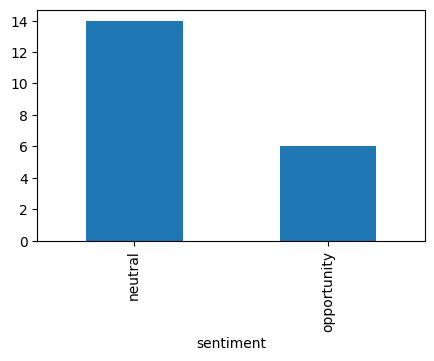

In [ ]:
# Let's plot the distribution again.
print(data_env[data_env["environmental"] == "environmental"].groupby("sentiment").count()["environmental"])
data_env[data_env["environmental"] == "environmental"].groupby("sentiment").count()["environmental"].plot(kind = "bar", figsize=(5, 3))

With that, we close today's tutorial. I hope, you found this helpful. I will update this file once the new tutorial on GPUs and large-scale analysis is out. Until then, feel free to read the [paper on the ESG BERTs](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4622514) or follow [me on LinkedIn](https://www.linkedin.com/in/tobias-schimanski-964077182/) to not miss out on new developments.